In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
stores = pd.read_csv("stores.csv")
oil = pd.read_csv("oil.csv")
holidays = pd.read_csv("holidays_events.csv")
print(train.head())
print(train.info())

   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB
None


In [3]:
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])
oil['date']=pd.to_datetime(oil['date'])
train = train.fillna(0)
oil = oil.ffill()

In [4]:
print(train.columns)

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')


In [5]:
print(stores.columns)

Index(['store_nbr', 'city', 'state', 'type', 'cluster'], dtype='object')


In [6]:
train = train.merge(stores, on='store_nbr', how='left')

In [7]:
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train['dayofweek'] = train['date'].dt.dayofweek
train['is_weekend'] = train['dayofweek'].isin([5,6]).astype(int)
train = pd.get_dummies(train, columns=['family', 'city', 'state', 'type'])

In [8]:
train = train.drop(['date'], axis=1)
x = train.drop('sales', axis=1)
y = train['sales']

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [10]:
x = train.drop('sales', axis=1)
y = train['sales']
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

In [11]:
train = train.sample(50000, random_state=42)

In [12]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [13]:
model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [14]:
preds = model.predict(x_val)

In [15]:
mae = mean_absolute_error(y_val, preds)
print("MAE:", mae)

MAE: 44.95281805789156


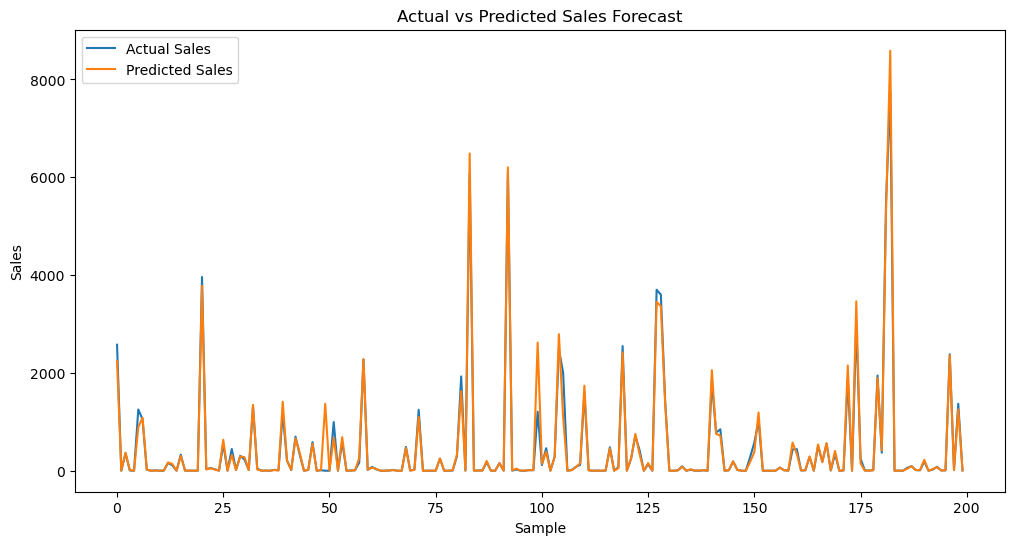

In [17]:
plt.figure(figsize=(12,6))
plt.plot(y_val.values[:200], label='Actual Sales')
plt.plot(preds[:200], label="Predicted Sales")
plt.title("Actual vs Predicted Sales Forecast")
plt.xlabel("Sample")
plt.ylabel("Sales")
plt.legend()
plt.show()

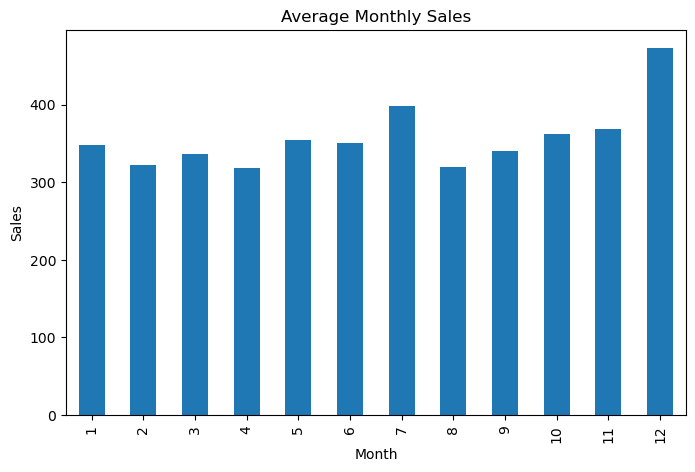

In [18]:
monthly_sales = train.groupby('month')['sales'].mean()
monthly_sales.plot(kind='bar', figsize=(8,5))
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [19]:
test = pd.read_csv("test.csv")
test = test.merge(stores, on='store_nbr', how='left')
test['date'] = pd.to_datetime(test['date'])
test['year'] = test['date'].dt.year
test['month'] = test['date'].dt.month
test['day'] = test['date'].dt.day
test['dayofweek'] = test['date'].dt.dayofweek
test['is_weekend'] = test['dayofweek'].isin([5,6]).astype(int)
test = pd.get_dummies(test)
test = test.reindex(columns=X.columns, fill_value=0)

test_preds = model.predict(test)
print(test_preds[:10])

NameError: name 'X' is not defined